<a href="https://colab.research.google.com/github/TxM1/hangzhou-logistics-anomaly-engine/blob/main/logistics_anomaly_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- DISTRICT DELAY ALERT ---
district
Xihu        9
Xiaoshan    8
Binjiang    7
Gongshu     6
dtype: int64


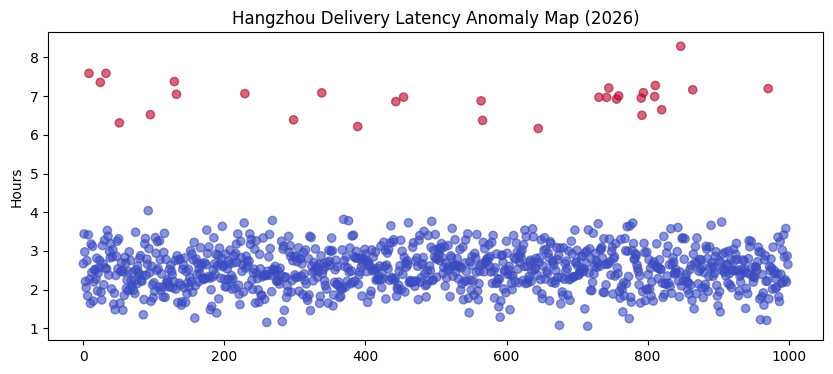

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
districts = ['Xihu', 'Binjiang', 'Gongshu', 'Xiaoshan']
data = {
    'order_id': range(1000),
    'district': np.random.choice(districts, 1000),
    'delivery_time_hrs': np.random.normal(2.5, 0.5, 1000)
}
df = pd.DataFrame(data)


df.loc[df.sample(30).index, 'delivery_time_hrs'] += 4.5


df['z_score'] = (df['delivery_time_hrs'] - df['delivery_time_hrs'].mean()) / df['delivery_time_hrs'].std()
df['is_anomaly'] = df['z_score'] > 2.5


bottlenecks = df[df['is_anomaly']].groupby('district').size().sort_values(ascending=False)
print("--- DISTRICT DELAY ALERT ---")
print(bottlenecks)


plt.figure(figsize=(10,4))
plt.scatter(df.index, df.delivery_time_hrs, c=df.is_anomaly, cmap='coolwarm', alpha=0.6)
plt.title("Hangzhou Delivery Latency Anomaly Map (2026)")
plt.ylabel("Hours")
plt.show()